- folium이란 Python에서 인터랙티브 지도를 그리기 위한 라이브러리
- geokakao란 카카오 지도 API를 이용한 지오코딩(주소 <-> 좌표변환)라이브러리

In [1]:
%pip install folium

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.4-cp312-cp312-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.4-cp312-cp312-win_amd64.whl (107 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install geokakao

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ------------- -------------------------- 7.6/22.9 MB 36.2 MB/s eta 0:00:01
   ----------------------- ---------------- 13.4/22.9 MB 31.1 MB/s eta 0:00:01
   -------------------------------- ------- 18.9/22.9 MB 30.6 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 29.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 38.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 18.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
특정 지역 지도 보기


In [3]:
import folium
import geokakao as gk

import webbrowser
import os

# 지도를 웹 브라우저에 표시
def showMap(map):
    map.save("map.html")    # 지도가 포함된 html 파일 생성
    filepath = os.getcwd()     # 현재 작업 폴더
    file_uri = 'file:///' + filepath + '/map.html'
    webbrowser.open_new_tab(file_uri)   # html 파일 오픈

In [4]:
# 지도 중심의 좌표를 알 때
loc = [37.54, 127.05]  # 위도 경도,
map = folium.Map(location=loc)  # 지도 객체 생성
showMap(map)    # 웹 브라우저에 지도 표시

In [5]:
# 지도 중심의 주소를 알 때
loc = gk.convert_address_to_coordinates('서울특별시 성북구 삼선교로 ')
print(loc)
showMap(map)

('37.5884411367178', '127.010631441044')


---
지도 위에 마커와 텍스트 표시하기

In [6]:
loc = gk.convert_address_to_coordinates('서울특별시 성북구 삼선교로 ')
print(loc)

('37.5884411367178', '127.010631441044')


In [7]:
map = folium.Map(location=loc, zoom_start=16)   # 지도 객체 생성

# popup : 마우스 클릭했을 때 표시할 텍스트를 입력합니다.
folium.Marker(location=loc, # 기본 마커 표시
            popup='경복궁').add_to(map)
showMap(map)    #웹브루우저에 지도 표시

---
마커 모양 변경하기

In [8]:
import folium
import geokakao as gk

loc = gk.convert_address_to_coordinates('강원특별자치도 강릉시 창해로 514')
print(loc)

('37.8057701120176', '128.907481194757')


In [9]:
map = folium.Map(location=loc, zoom_start=13)   # 지도 객체 생성
folium.Marker(location=loc,     # 마커 표시
            icon=folium.Icon(color='red', icon='star', prefix='fa')).add_to(map)
showMap(map)    # 웹 브라우저에 지도 표시

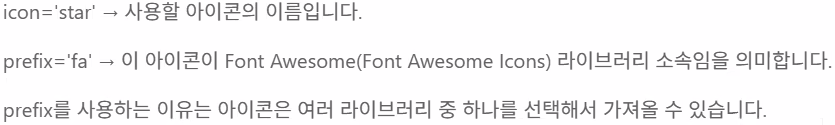

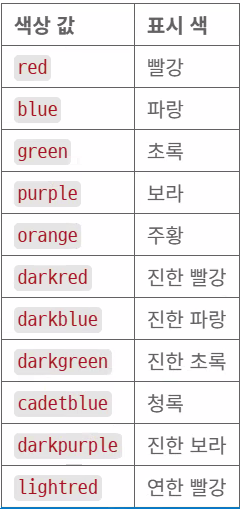

---
마커 위치에 텍스트 추가하기

In [10]:
import folium
import geokakao as gk

loc = gk.convert_address_to_coordinates('강원특별자치도 강릉시 창해로 514')
print(loc)

# zoom_start=13 : 초기 zoom level을 13으로 설정합니다.
# 구 단위 또는 동네 단위로, 주요 도로가 식별됩니다.
map = folium.Map(location=loc, zoom_start=13)   # 지도 객체 생성
folium.Marker(location=loc, # 마커 표시
            icon=folium.Icon(color='red', icon='star')).add_to(map)
showMap(map)    # 웹브라우저에 지도 표시

('37.8057701120176', '128.907481194757')


### <div style="font-size: 12px;color:blue;background-color:rgba(255, 255, 255, 0.2);width:85px;text-align:left;margin:0px;><b>경포해수욕장</b></div>.


In [11]:
# 마커 위치에 텍스트 추가
html_start = '<div \
style="\
font-size:12px;\
color:blue;\
background-color:rgba(255, 255, 255, 0.2);\
width:85px;\
text-align:left;\
margin:0px;\
"><b>'
html_end = '</d></div>'

In [12]:
# 사용자가 지정한 HTML 텍스트(글자)를 직접 노출시키기 위한 설정입니다.
folium.Marker(location=loc,
            icon=folium.DivIcon(
                icon_anchor=(0, 0),  # 텍스트 위치 설정
                html= html_start+'경포해수욕장'+html_end # 실제로 지도에 보여줄 내용입니다.
            )).add_to(map)
showMap(map)    # 웹 브라우저에 지도표시

---
다수의 마커

In [13]:
import folium
import geokakao as gk
import pandas as pd
# 관광지 정보를 데이터프레임으로 저장
names = ['용두암', '성산일출봉', '정방폭포',
         '중문관광단지', '한라산1100고지', '차귀도']
addr = ['제주시 용두암길 15',
        '서귀포시 성산읍 성산리',
        '서귀포시 동홍동 299-3',
        '서귀포시 중문동 2624-1',
        '서귀포시 색달동 산1-2',
        '제주시 한경면 고산리 산 117']
dict = {"names": names, "addr": addr}
df = pd.DataFrame(dict)
print(df)

       names               addr
0        용두암        제주시 용두암길 15
1      성산일출봉       서귀포시 성산읍 성산리
2       정방폭포     서귀포시 동홍동 299-3
3     중문관광단지    서귀포시 중문동 2624-1
4  한라산1100고지      서귀포시 색달동 산1-2
5        차귀도  제주시 한경면 고산리 산 117


In [14]:
# 데이터프레임의 주소 컬럼(addr)을 이용해 위도(latitude)와 경도(longitudie)를 구한 뒤,
# 그 결과를 새로운 컬럼으로 df에 추가합니다.
gk.add_coordinates_to_dataframe(df,'addr')
print(df)
print(df.dtypes)    # 추가된 위도와 경도의 자료형이 문자형(object)입니다.

       names               addr   decimalLatitude  decimalLongitude
0        용두암        제주시 용두암길 15  33.5148035919525  126.511798046978
1      성산일출봉       서귀포시 성산읍 성산리  33.4641549468628  126.933094402743
2       정방폭포     서귀포시 동홍동 299-3  33.2450439717872  126.571611812583
3     중문관광단지    서귀포시 중문동 2624-1  33.2458014088806  126.420647253077
4  한라산1100고지      서귀포시 색달동 산1-2  33.3575245371214  126.462896523457
5        차귀도  제주시 한경면 고산리 산 117  33.3114857877205  126.146243639486
names               str
addr                str
decimalLatitude     str
decimalLongitude    str
dtype: object


In [15]:
# 위도(latitude), 경도(longitude)
# 문자열 좌표값을 숫자로 변환(지도의 중심점 계산을 위해 변환)
df.decimalLatitude = pd.to_numeric(df.decimalLatitude)
df.decimalLongitude = pd.to_numeric(df.decimalLongitude)
print(df.dtypes)

names                   str
addr                    str
decimalLatitude     float64
decimalLongitude    float64
dtype: object


In [16]:
# 지도의 중심점 계산
center = [df.decimalLatitude.mean(), df.decimalLongitude.mean()]
print(center)

[np.float64(33.35646904072083), np.float64(126.50771527972067)]


In [17]:
loc1 = gk.convert_address_to_coordinates('제주시 용두암길 15')
print(loc1)

map = folium.Map(location=loc1, zoom_start=13)   # 지도 객체 생성
folium.Marker(location=loc1, # 마커 표시
            icon=folium.Icon(color='red', icon='star')).add_to(map)

folium.Marker(location=loc1,
            icon=folium.DivIcon(
                icon_anchor=(0, 0),  # 텍스트 위치 설정
                html= html_start+'용두암'+html_end # 실제로 지도에 보여줄 내용입니다.
            )).add_to(map)
showMap(map)

('33.5148035919525', '126.511798046978')


In [18]:
loc = gk.convert_address_to_coordinates('서귀포시 성산읍 성산리')
print(loc)

map = folium.Map(location=loc, zoom_start=13)   # 지도 객체 생성
folium.Marker(location=loc, # 마커 표시
            icon=folium.Icon(color='red', icon='star')).add_to(map)
showMap(map)

folium.Marker(location=loc,
            icon=folium.DivIcon(
                icon_anchor=(0, 0),  # 텍스트 위치 설정
                html= html_start+'성산일출봉'+html_end # 실제로 지도에 보여줄 내용입니다.
            )).add_to(map)
showMap(map)

('33.4641549468628', '126.933094402743')


In [19]:
loc = gk.convert_address_to_coordinates('서귀포시 동홍동 299-3')
print(loc)

map = folium.Map(location=loc, zoom_start=13)   # 지도 객체 생성
folium.Marker(location=loc, # 마커 표시
            icon=folium.Icon(color='red', icon='star')).add_to(map)
showMap(map)

folium.Marker(location=loc,
            icon=folium.DivIcon(
                icon_anchor=(0, 0),  # 텍스트 위치 설정
                html= html_start+'정방폭포'+html_end # 실제로 지도에 보여줄 내용입니다.
            )).add_to(map)
showMap(map)

('33.2450439717872', '126.571611812583')


In [20]:
loc = gk.convert_address_to_coordinates('서귀포시 중문동 2624-1')
print(loc)

map = folium.Map(location=loc, zoom_start=13)   # 지도 객체 생성
folium.Marker(location=loc, # 마커 표시
            icon=folium.Icon(color='red', icon='star')).add_to(map)
showMap(map)

folium.Marker(location=loc,
            icon=folium.DivIcon(
                icon_anchor=(0, 0),  # 텍스트 위치 설정
                html= html_start+'중문관광단지'+html_end # 실제로 지도에 보여줄 내용입니다.
            )).add_to(map)
showMap(map)

('33.2458014088806', '126.420647253077')


In [21]:
loc = gk.convert_address_to_coordinates('서귀포시 색달동 산1-2')
print(loc)

map = folium.Map(location=loc, zoom_start=13)   # 지도 객체 생성
folium.Marker(location=loc, # 마커 표시
            icon=folium.Icon(color='red', icon='star')).add_to(map)
showMap(map)

folium.Marker(location=loc,
            icon=folium.DivIcon(
                icon_anchor=(0, 0),  # 텍스트 위치 설정
                html= html_start+'한라산1100고지'+html_end # 실제로 지도에 보여줄 내용입니다.
            )).add_to(map)
showMap(map)

('33.3575245371214', '126.462896523457')


In [22]:
loc = gk.convert_address_to_coordinates('제주시 한경면 고산리 산 117')
print(loc)

map = folium.Map(location=loc, zoom_start=13)   # 지도 객체 생성
folium.Marker(location=loc, # 마커 표시
            icon=folium.Icon(color='red', icon='star')).add_to(map)
showMap(map)

folium.Marker(location=loc,
            icon=folium.DivIcon(
                icon_anchor=(0, 0),  # 텍스트 위치 설정
                html= html_start+'차귀도'+html_end # 실제로 지도에 보여줄 내용입니다.
            )).add_to(map)
showMap(map)

('33.3114857877205', '126.146243639486')


In [25]:
# 지도 객체 생성
map = folium.Map(location=center, zoom_start=10)

# 스타일 설정을 위한 HTML 템플릿
html_style = """
<div style="
    font-size:12px;
    color:blue;
    background-color:rgba(255, 255, 255, 0.2);
    width:85px;
    text-align:left;
    margin:0px;
"><b>{}</b></div>
"""

# 하나의 반복문에서 마커와 텍스트 모두 추가
for i in range(len(df)):
    lat, lng = df.iloc[i, 2], df.iloc[i, 3]
    name = str(df.iloc[i, 0])
    
    # 1. 별 모양 마커 추가
    folium.Marker(
        location=[lat, lng],
        icon=folium.Icon(color='red', icon='star')
    ).add_to(map)
    
    # 2. 텍스트 마커 추가 (DivIcon)
    folium.Marker(
        location=[lat, lng],
        icon=folium.DivIcon(
            icon_anchor=(0, -5),  # 아이콘 대비 위치 조정
            html=html_style.format(name)
        )
    ).add_to(map)

# 최종 지도 출력
showMap(map)